In [12]:
import geopandas as gpd

In [28]:
def filter_canton(cantonname, buffer_m=10000):
    """
    Returns the geometry of a Swiss canton and its bounding box,
    optionally expanded by a buffer.

    Parameters
    ----------
    cantonname : str
        Name of the canton to filter.
    buffer_m : float, optional
        Buffer distance in meters around the canton geometry (default: 0).

    Returns
    -------
    canton_buffered : GeoDataFrame
        Geometry of the canton including the buffer.
    canton_bbox : tuple
        Bounding box (xmin, ymin, xmax, ymax) of the buffered canton.
    """
    boundaries_path = "C:/ZHAW/5.Semester/PA2/data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
    cantons = gpd.read_file(boundaries_path, layer="tlm_kantonsgebiet")
    
    # Filter canton
    canton = cantons[cantons["name"] == cantonname]
    
    # Apply buffer if requested
    if buffer_m > 0:
        canton_buffered = canton.copy()
        canton_buffered["geometry"] = canton_buffered.geometry.buffer(buffer_m)
    else:
        canton_buffered = canton
    
    # Compute bounding box
    xmin, ymin, xmax, ymax = canton_buffered.total_bounds
    canton_bbox = (xmin, ymin, xmax, ymax)
    
    return canton_buffered, canton_bbox

In [31]:
def load_swisstlm_for_canton(layername, bbox, canton):
    tlm_path = "C:/ZHAW/5.Semester/PA2/data/SWISSTLM3D_2025.gpkg"
    layer = gpd.read_file(tlm_path, layer=layername, bbox=bbox)
    canton_layer = gpd.clip(layer, bbox)
    return canton_layer

In [29]:
sh, sh_bbox = filter_canton("Schaffhausen")

Layer 'tlm_bb_bodenbedeckung' loaded and clipped to canton + buffer
Number of features: 15383


<Axes: >

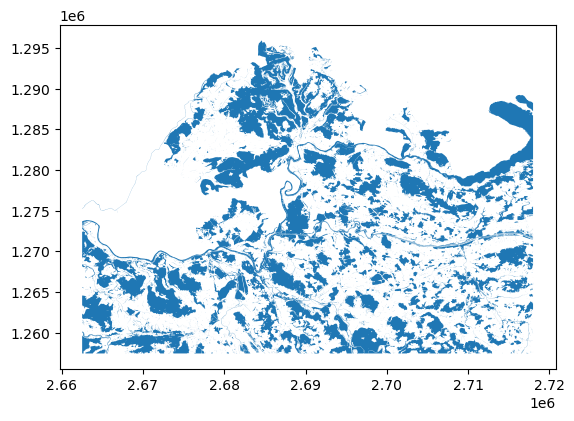

In [32]:
landcover_sh = load_swisstlm_for_canton("tlm_bb_bodenbedeckung", sh_bbox, sh)

print(f"Layer 'tlm_bb_bodenbedeckung' loaded and clipped to canton + buffer")
print("Number of features:", len(landcover_sh))

# Optional: visualize
landcover_sh.plot()

In [33]:
# ============================================================
# Title: Filter Canton and Load SWISSTLM Data Without Buffer
# Description: Returns the canton geometry and bounding box,
#              and loads a single SWISSTLM layer within this bounding box.
# ============================================================

import geopandas as gpd

def filter_canton(cantonname):
    """
    Returns the geometry of a Swiss canton and its bounding box.

    Parameters
    ----------
    cantonname : str
        Name of the canton to filter.

    Returns
    -------
    canton : GeoDataFrame
        Geometry of the selected canton.
    canton_bbox : tuple
        Bounding box (xmin, ymin, xmax, ymax) of the canton.
    """
    boundaries_path = "C:/ZHAW/5.Semester/PA2/data/swissBOUNDARIES3D_1_5_LV95_LN02.gpkg"
    cantons = gpd.read_file(boundaries_path, layer="tlm_kantonsgebiet")
    
    # Filter canton
    canton = cantons[cantons["name"] == cantonname]
    
    if canton.empty:
        raise ValueError(f"Canton '{cantonname}' not found.")
    
    # Compute bounding box
    xmin, ymin, xmax, ymax = canton.total_bounds
    canton_bbox = (xmin, ymin, xmax, ymax)
    
    return canton, canton_bbox


def load_swisstlm_for_canton(layername, canton_bbox):
    """
    Loads a single SWISSTLM layer for a given canton bounding box.

    Parameters
    ----------
    layername : str
        Name of the SWISSTLM layer to load (e.g., 'tlm_bauten_gebaeude_footprint').
    canton_bbox : tuple
        Bounding box (xmin, ymin, xmax, ymax) of the canton.

    Returns
    -------
    clipped_layer : GeoDataFrame
        GeoDataFrame of the requested layer within the canton bounding box.
    """
    tlm_path = "C:/ZHAW/5.Semester/PA2/data/SWISSTLM3D_2025.gpkg"

    try:
        # Load layer within bounding box
        layer = gpd.read_file(tlm_path, layer=layername, bbox=canton_bbox)

        if layer.empty:
            print(f"⚠️ Layer '{layername}' is empty in the selected canton.")
            return gpd.GeoDataFrame(columns=layer.columns)

        return layer

    except Exception as e:
        print(f"❌ Could not load layer '{layername}': {e}")
        return gpd.GeoDataFrame()  # empty GeoDataFrame


Bounding box: (np.float64(2672514.567), np.float64(1267448.052), np.float64(2707983.136), np.float64(1295933.698))
Number of features: 7213


<Axes: >

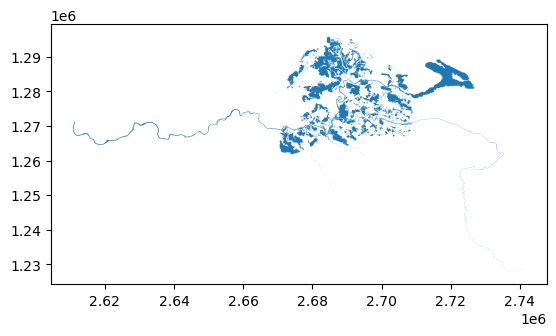

In [34]:
# 1️⃣ Filter canton and get bounding box
cantonname = "Schaffhausen"
canton, canton_bbox = filter_canton(cantonname)
print("Bounding box:", canton_bbox)

# 2️⃣ Load a single SWISSTLM layer within this bounding box
layername = "tlm_bb_bodenbedeckung"
clipped_layer = load_swisstlm_for_canton(layername, canton_bbox)
print("Number of features:", len(clipped_layer))

# Optional: visualize
clipped_layer.plot()
